In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
#read in all words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
#build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [109]:
#build the dataset
block_size = 3
X , Y =[],[]
for w in words:
    #print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix  = stoi[ch]
        X.append(context)
        #print(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context),'--->',itos[ix])
        context = context[1:]+[ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [110]:
X.shape,X.dtype

(torch.Size([228146, 3]), torch.int64)

In [173]:
#build the dataset
# training set,dev/validation set,test set

def build_dataset(words):
    block_size = 3
    X , Y =[],[]
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix  = stoi[ch]
            X.append(context)
            #print(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'--->',itos[ix])
            context = context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y


import random
random.seed(12)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182607, 3]) torch.Size([182607])
torch.Size([22784, 3]) torch.Size([22784])
torch.Size([22755, 3]) torch.Size([22755])


In [20]:
C = torch.randn((27,2))

In [29]:
C[5]

tensor([-1.3485, -0.7584])

In [30]:
# torch的索引方法
C[torch.tensor([5,6,7])]
C[[5,6,7]]
C[[5,6,7,7,7,7]]

tensor([[-1.3485, -0.7584],
        [ 0.3611,  0.0445],
        [-1.1184,  0.4890],
        [-1.1184,  0.4890],
        [-1.1184,  0.4890],
        [-1.1184,  0.4890]])

In [33]:
C[X].shape

torch.Size([32, 3, 2])

In [48]:
#两者等价
print(X[13,2])
print(C[X][13,2])
print(C[1])

tensor(1)
tensor([ 0.4740, -0.0697])
tensor([ 0.4740, -0.0697])


In [50]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [51]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [71]:
#矩阵索引
emb[:,0,:].shape


### 以下三种方法将emb由32*3*2变为32*6
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1)
torch.cat(torch.unbind(emb,1),1)
#pytorch内部存储的数据，一维形式存储 emb.storage()
emb.view(32,6)

torch.Size([32, 2])

In [79]:
h = torch.tanh(emb.view(emb.shape[0],6) @ W1 + b1)
#h = emb.view(-1,6) @ W1 + b1  当为-1时，pytorch可以自动推导
h

tensor([[-0.9602,  1.0000, -1.0000,  ...,  0.9996, -0.2775, -0.2022],
        [-0.9703,  0.9998, -1.0000,  ...,  0.9173, -0.9163,  0.9597],
        [ 0.4647,  0.7647, -0.9999,  ...,  0.0259, -0.9651,  0.9952],
        ...,
        [-0.8170, -0.9998,  1.0000,  ..., -0.9988,  0.1120,  0.9572],
        [ 0.9946, -1.0000,  0.9995,  ...,  0.8880, -0.1687,  0.6711],
        [-0.9954, -0.9964,  1.0000,  ...,  0.9911,  0.9976, -0.9883]])

In [85]:
# 输出共有27种结果
W2 = torch.randn((100,27))
b2 = torch.randn(27)
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [86]:
# 取指数后进行归一化
counts = logits.exp()
prob = counts / counts.sum(1,keepdims = True)
prob.shape

torch.Size([32, 27])

In [91]:
# 为Y中存储的真实值分配的概率
prob[torch.arange(32),Y]
# 对数损失函数
loss = - prob[torch.arange(32),Y].log().mean()
loss

tensor(17.2208)

In [ ]:
# ============================以下为MLP的整体代码================================

In [209]:
# 汇总
g = torch.Generator().manual_seed(2147483647)
C= torch.randn((27,10),generator = g)
W1 = torch.randn((30,300))
b1 = torch.randn(300)
W2 = torch.randn((300,27))
b2 = torch.randn(27)
parameters = [C,W1,b1,W2,b2]
sum(p.nelement() for p in parameters)

17697

In [232]:
for p in parameters:
    p.requires_grad = True

In [233]:
lre = torch.linspace(-1,1,1000)
lrs = 10**lre

In [234]:
lri = []
lossi = []
stepi = []

In [241]:

for i in range(100000):
    # minbatch constuct
    ix = torch.randint(0,Xtr.shape[0],(32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims = True)
    # # 对数损失函数
    # loss = - prob[torch.arange(32),Y].log().mean()
    # 注释的三行代码可执行用cross_entropy()函数代替，计算对数平均值作为损失函数,且统一函数效率更高，可以简化部分的运算
    loss=F.cross_entropy(logits,Ytr[ix])
    #print (loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    # lr = lrs[i]
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad


    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print (loss.item())

2.4506030082702637


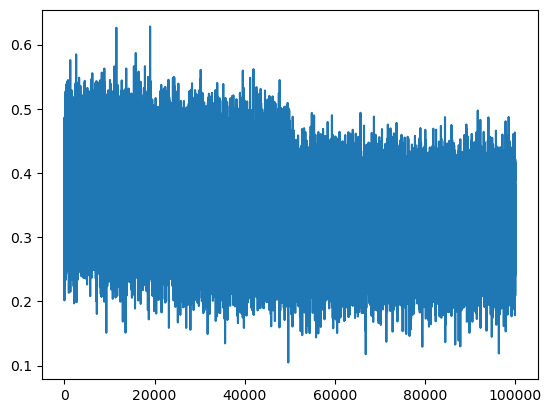

In [242]:
# plt.plot(lri,lossi)
plt.plot(stepi,lossi)

In [243]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1)
logits = h @ W2 + b2
loss=F.cross_entropy(logits,Ydev)
loss

tensor(2.1682, grad_fn=<NllLossBackward0>)

In [238]:
emb = C[Xtr]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1)
logits = h @ W2 + b2
loss=F.cross_entropy(logits,Ytr)
loss

tensor(2.1528, grad_fn=<NllLossBackward0>)

In [245]:
emb = C[Xte]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1)
logits = h @ W2 + b2
loss=F.cross_entropy(logits,Yte)
loss

tensor(2.1698, grad_fn=<NllLossBackward0>)

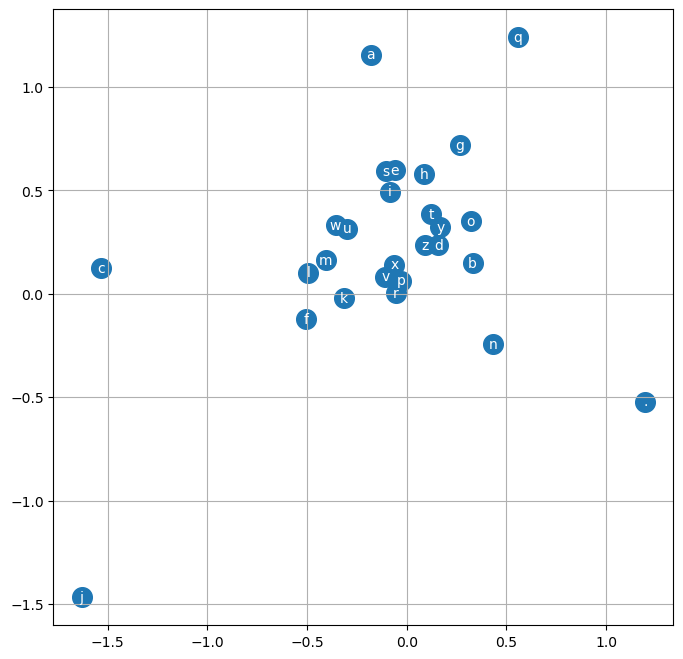

In [244]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s = 200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color='white')
plt.grid('mirror')